# Prakruti Chatbot — Random Forest Training (Final, Fresh-Run Safe)

This notebook trains **only the Random Forest classifier** for the `Dosha` target.

**Important architecture:**
- Random Forest → dominant Dosha class
- Rule-based scoring (implemented separately later) → Vata/Pitta/Kapha percentages
- Random Forest probabilities are **not** Vata/Pitta/Kapha percentages.

The notebook is designed to run from a fresh Jupyter kernel without depending on cell execution order.


## 1. Imports

In [1]:
import json
import platform
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


## 2. Project paths and configuration

In [2]:
TARGET_COLUMN = "Dosha"
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ESTIMATORS = 300
CV_FOLDS = 5

def find_project_root(start_path: Path) -> Path:
    """Find the project root by locating data/raw/Data.csv."""
    start_path = start_path.resolve()
    candidates = [start_path] + list(start_path.parents)
    for candidate in candidates:
        if (candidate / "data" / "raw" / "Data.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find project root. Expected: <project_root>/data/raw/Data.csv"
    )

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Data.csv"
MODEL_DIR = PROJECT_ROOT / "ml" / "models"
MODEL_PATH = MODEL_DIR / "prakruti_random_forest.pkl"
METADATA_PATH = MODEL_DIR / "prakruti_random_forest_metadata.json"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Model:", MODEL_PATH)
print("Metadata:", METADATA_PATH)


Project root: D:\prakruti-chatbot
Dataset: D:\prakruti-chatbot\data\raw\Data.csv
Model: D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
Metadata: D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json


## 3. Load dataset

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data.csv not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

if df.empty:
    raise ValueError("Data.csv is empty.")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1200, 30)


,Body Size,Body Weight,Height,Bone Structure,Complexion,General feel of skin,Texture of Skin,Hair Color,Appearance of Hair,Shape of face,...,Dosha,Metabolism Type,Climate Preference,Stress Levels,Sleep Patterns,Dietary Habits,Physical Activity Level,Water Intake,Digestion Quality,Skin Sensitivity
0,Medium,Moderate - no difficulties in gaining or losin...,Average,"Large, broad shoulders , heavy bone structure","White, pale, tans easily","Dry and thin, cool to touch, rough","Dry, pigments and aging","Black/Brown,dull","Straight, oily","Long, angular, thin",...,vata+pitta,fast,warm,moderate,moderate,vegan,moderate,moderate,moderate,sensitive
1,Medium,Moderate - no difficulties in gaining or losin...,Short,Medium bone structure,Fair-skin sunburns easily,"Dry and thin, cool to touch, rough",Oily,"Red, light brown, yellow","Dry, black, knotted, brittle","Long, angular, thin",...,vata+pitta,moderate,cool,moderate,moderate,vegetarian,sedentary,high,moderate,normal
2,Slim,Moderate - no difficulties in gaining or losin...,Average,Medium bone structure,Fair-skin sunburns easily,"Smooth and warm, oily T-zone",Oily,"Black/Brown,dull","Dry, black, knotted, brittle","Long, angular, thin",...,Pitta,fast,warm,moderate,short,omnivorous,moderate,moderate,moderate,normal
3,Slim,Moderate - no difficulties in gaining or losin...,Short,"Light, Small bones, prominent joints",Fair-skin sunburns easily,"Dry and thin, cool to touch, rough",Oily,"Black/Brown,dull","Straight, oily","Large, round, full",...,vata+pitta,slow,moderate,low,long,omnivorous,sedentary,moderate,strong,normal
4,Large,Moderate - no difficulties in gaining or losin...,Short,Medium bone structure,"Dark-Complexion, tans easily","Smooth and warm, oily T-zone",Oily,"Black/Brown,dull","Dry, black, knotted, brittle","Long, angular, thin",...,vata+pitta,slow,cool,low,moderate,omnivorous,moderate,moderate,weak,normal


## 4. Validate target and dataset structure

In [4]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found. "
        f"Available columns: {list(df.columns)}"
    )

missing = df.isna().sum()
missing_nonzero = missing[missing > 0]

print("Target column:", TARGET_COLUMN)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Exact duplicate rows:", int(df.duplicated().sum()))

print("\nMissing values:")
if missing_nonzero.empty:
    print("No missing values found.")
else:
    display(missing_nonzero.to_frame("missing_values"))

print("\nTarget distribution:")
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame("count"))

if df[TARGET_COLUMN].isna().any():
    raise ValueError("Target column contains missing values. Resolve them before training.")


Target column: Dosha
Rows: 1200
Columns: 30
Exact duplicate rows: 1

Missing values:
No missing values found.

Target distribution:


,count
Dosha,
vata+pitta,624
Vata,264
Pitta,144
Kapha,72
pitta+kapha,48
vata+kapha,48


## 5. Remove exact duplicate rows

In [5]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)
duplicates_removed = rows_before - rows_after

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", duplicates_removed)


Rows before: 1200
Rows after: 1199
Duplicates removed: 1


## 6. Define features and target

In [6]:
X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].astype(str).copy()

if X.shape[1] == 0:
    raise ValueError("No input features remain after removing the target column.")
if y.nunique() < 2:
    raise ValueError("Random Forest classification requires at least two target classes.")

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Input features:", X.shape[1])
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

if numerical_features:
    raise ValueError(
        "This dataset is expected to contain categorical questionnaire inputs, "
        f"but numerical features were found: {numerical_features}"
    )

class_counts = y.value_counts()
print("\nClasses:")
print(class_counts)

if class_counts.min() < CV_FOLDS:
    raise ValueError(
        f"The smallest class has {class_counts.min()} samples, but {CV_FOLDS}-fold "
        "stratified cross-validation requires at least that many samples per class."
    )


Input features: 29
Categorical features: 29
Numerical features: 0

Classes:
Dosha
vata+pitta     624
Vata           263
Pitta          144
Kapha           72
pitta+kapha     48
vata+kapha      48
Name: count, dtype: int64


C:\Users\kakar\AppData\Local\Temp\ipykernel_4660\845459836.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


## 7. Stratified train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts().to_frame("count"))

print("Testing class distribution:")
display(y_test.value_counts().to_frame("count"))


Training samples: 959
Testing samples: 240

Training class distribution:


,count
Dosha,
vata+pitta,499
Vata,210
Pitta,115
Kapha,58
vata+kapha,39
pitta+kapha,38


Testing class distribution:


,count
Dosha,
vata+pitta,125
Vata,53
Pitta,29
Kapha,14
pitta+kapha,10
vata+kapha,9


## 8. One-Hot Encoding + Random Forest pipeline

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="drop",
)

rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model),
    ]
)

print(model_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Body Size', 'Body Weight',
                                                   'Height', 'Bone Structure',
                                                   'Complexion',
                                                   'General feel of skin',
                                                   'Texture of Skin',
                                                   'Hair Color',
                                                   'Appearance of Hair',
                                                   'Shape of face', 'Eyes',
                                                   'Eyelashes',
                                                   'Blinking of Eyes', 'Cheeks',
                                                   'Nose', 'Teeth and gums',
        

## 9. Train the evaluation model

In [9]:
model_pipeline.fit(X_train, y_train)
print("Random Forest training completed successfully.")


Random Forest training completed successfully.


## 10. Held-out test-set evaluation

In [10]:
y_pred = model_pipeline.predict(X_test)

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
}

metrics_table = pd.DataFrame({
    "Metric": list(test_metrics.keys()),
    "Score": list(test_metrics.values()),
})
display(metrics_table.style.format({"Score": "{:.4f}"}))


,Metric,Score
0,Accuracy,1.0000
1,Macro Precision,1.0000
2,Macro Recall,1.0000
3,Macro F1,1.0000


## 11. Classification report

In [11]:
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

       Kapha       1.00      1.00      1.00        14
       Pitta       1.00      1.00      1.00        29
        Vata       1.00      1.00      1.00        53
 pitta+kapha       1.00      1.00      1.00        10
  vata+kapha       1.00      1.00      1.00         9
  vata+pitta       1.00      1.00      1.00       125

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## 12. Confusion matrix

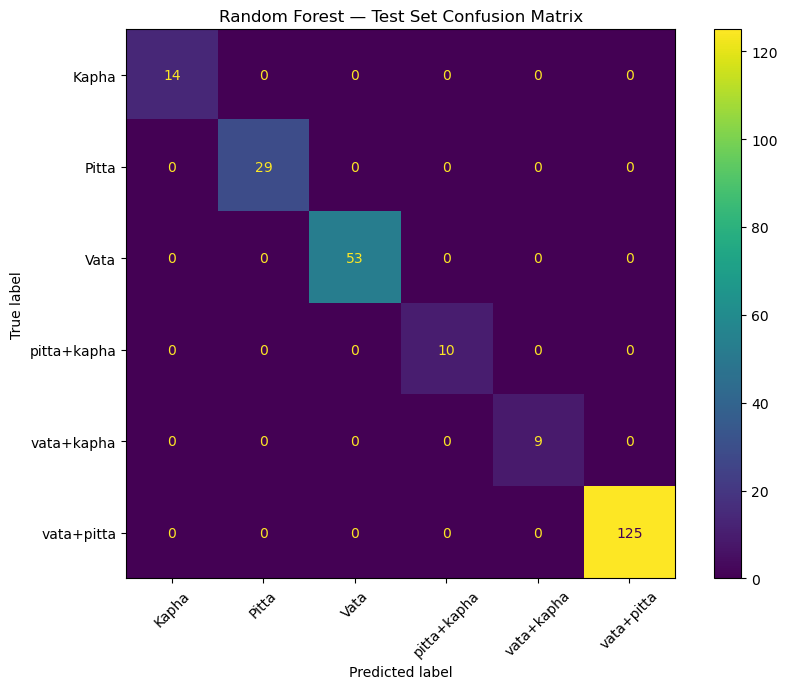

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
).plot(ax=ax, xticks_rotation=45, values_format="d")
ax.set_title("Random Forest — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


## 13. Five-fold stratified cross-validation

In [13]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

cv_results = cross_validate(
    model_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision_macro"].mean(),
        cv_results["test_recall_macro"].mean(),
        cv_results["test_f1_macro"].mean(),
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision_macro"].std(),
        cv_results["test_recall_macro"].std(),
        cv_results["test_f1_macro"].std(),
    ],
})
display(cv_summary.style.format({"Mean": "{:.4f}", "Std": "{:.4f}"}))


,Metric,Mean,Std
0,Accuracy,1.0000,0.0000
1,Macro Precision,1.0000,0.0000
2,Macro Recall,1.0000,0.0000
3,Macro F1,1.0000,0.0000


## 14. Cross-validation results by fold

In [14]:
fold_results = pd.DataFrame({
    "Fold": range(1, CV_FOLDS + 1),
    "Accuracy": cv_results["test_accuracy"],
    "Macro Precision": cv_results["test_precision_macro"],
    "Macro Recall": cv_results["test_recall_macro"],
    "Macro F1": cv_results["test_f1_macro"],
})

display(fold_results.style.format({
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
}))


,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,1.0000,1.0000,1.0000,1.0000
1,2,1.0000,1.0000,1.0000,1.0000
2,3,1.0000,1.0000,1.0000,1.0000
3,4,1.0000,1.0000,1.0000,1.0000
4,5,1.0000,1.0000,1.0000,1.0000


## 15. Leakage and perfect-score diagnostics

In [15]:
# Check whether an identical raw feature pattern occurs in both train and test.
train_keys = set(map(tuple, X_train.astype(str).to_numpy()))
test_keys = set(map(tuple, X_test.astype(str).to_numpy()))
train_test_exact_overlap = len(train_keys.intersection(test_keys))

# Check whether any single questionnaire feature perfectly determines the target.
feature_purity = {}
for column in X.columns:
    grouped = pd.crosstab(X[column].astype(str), y)
    purity = (grouped.max(axis=1) / grouped.sum(axis=1)).max()
    feature_purity[column] = float(purity)

max_single_feature_purity = max(feature_purity.values())
max_purity_feature = max(feature_purity, key=feature_purity.get)

print("Exact train/test feature-pattern overlap:", train_test_exact_overlap)
print("Highest single-feature target purity:", f"{max_single_feature_purity:.4f}")
print("Feature with highest purity:", max_purity_feature)

if test_metrics["Macro F1"] == 1.0 or cv_results["test_f1_macro"].mean() == 1.0:
    print("\nWARNING: PERFECT-SCORE REVIEW REQUIRED")
    print("Perfect scores are not automatically proof of a problem, but dataset/label provenance and leakage should be documented before claiming the model is highly generalizable.")


Exact train/test feature-pattern overlap: 0
Highest single-feature target purity: 0.7419
Feature with highest purity: Appetite

Perfect scores are not automatically proof of a problem, but dataset/label provenance and leakage should be documented before claiming the model is highly generalizable.


## 16. Random Forest feature importance

In [16]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
fitted_rf = model_pipeline.named_steps["classifier"]
feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_rf.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))


,feature,importance
45,"categorical__Teeth and gums_Big, White, Strong...",0.055568
30,"categorical__Eyes_Big, round, beautiful, glowi...",0.045175
3,categorical__Body Weight_Heavy - difficulties ...,0.038408
5,categorical__Body Weight_Moderate - no difficu...,0.034670
14,"categorical__Complexion_White, pale, tans easily",0.034543
49,"categorical__Lips_Lips are soft, medium-sized",0.029014
51,"categorical__Nails_Dry, Rough, Brittle, Break",0.026151
9,"categorical__Bone Structure_Large, broad shoul...",0.025913
0,categorical__Body Size_Large,0.025876
25,"categorical__Appearance of Hair_Straight, oily",0.023461


## 17. Train final model on all cleaned data

In [17]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="drop",
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

final_model.fit(X, y)
print("Final model trained on all cleaned data.")


Final model trained on all cleaned data.


## 18. Save the trained model

In [18]:
joblib.dump(final_model, MODEL_PATH)

if not MODEL_PATH.exists():
    raise IOError(f"Model file was not created: {MODEL_PATH}")

print("Model saved:", MODEL_PATH)
print("File size (bytes):", MODEL_PATH.stat().st_size)


Model saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
File size (bytes): 3871874


## 19. Save model metadata

In [19]:
metadata = {
    "model_name": "RandomForestClassifier",
    "pipeline_contains_preprocessing": True,
    "target_column": TARGET_COLUMN,
    "problem_type": "multiclass_classification",
    "classes": sorted(y.unique().tolist()),
    "n_classes": int(y.nunique()),
    "n_raw_features": int(X.shape[1]),
    "raw_feature_columns": X.columns.tolist(),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "n_estimators": N_ESTIMATORS,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "rows_before_deduplication": int(rows_before),
    "rows_after_deduplication": int(rows_after),
    "duplicate_rows_removed": int(duplicates_removed),
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "cv_macro_f1_mean": float(cv_results["test_f1_macro"].mean()),
    "cv_macro_f1_std": float(cv_results["test_f1_macro"].std()),
    "train_test_exact_feature_overlap": int(train_test_exact_overlap),
    "max_single_feature_target_purity": float(max_single_feature_purity),
    "max_single_feature_purity_feature": max_purity_feature,
    "python_version": sys.version,
    "platform": platform.platform(),
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", METADATA_PATH)


Metadata saved: D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json


## 20. Reload and verify the saved model

In [20]:
loaded_model = joblib.load(MODEL_PATH)

if not isinstance(loaded_model, Pipeline):
    raise TypeError("Saved model is not a scikit-learn Pipeline.")

loaded_predictions = loaded_model.predict(X_test)
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Loaded object:", type(loaded_model).__name__)
print(f"Reloaded model accuracy on test set: {loaded_accuracy:.4f}")

if not np.array_equal(y_pred, loaded_predictions):
    raise AssertionError("Reloaded model predictions do not match the original predictions.")

print("Model reload verification: PASSED")


Loaded object: Pipeline
Reloaded model accuracy on test set: 1.0000
Model reload verification: PASSED


## 21. Example inference

In [21]:
sample = X_test.iloc[[0]].copy()
prediction = loaded_model.predict(sample)[0]

print("Predicted Dosha:", prediction)
print("Actual Dosha:   ", y_test.iloc[0])


Predicted Dosha: Pitta
Actual Dosha:    Pitta


## 22. Optional Random Forest class probabilities

In [22]:
probabilities = loaded_model.predict_proba(sample)[0]
probability_table = pd.DataFrame({
    "Dosha Class": loaded_model.classes_,
    "Model Probability": probabilities,
}).sort_values("Model Probability", ascending=False)

display(probability_table.style.format({"Model Probability": "{:.4f}"}))

print("These are Random Forest class probabilities only; do not present them as Vata/Pitta/Kapha percentages.")


,Dosha Class,Model Probability
1,Pitta,1.0000
0,Kapha,0.0000
2,Vata,0.0000
3,pitta+kapha,0.0000
4,vata+kapha,0.0000
5,vata+pitta,0.0000


These are Random Forest class probabilities only; do not present them as Vata/Pitta/Kapha percentages.


## 23. FastAPI deployment-readiness checks

In [23]:
def validate_inference_frame(frame: pd.DataFrame) -> None:
    expected = X.columns.tolist()
    actual = frame.columns.tolist()
    missing_cols = [c for c in expected if c not in actual]
    extra_cols = [c for c in actual if c not in expected]
    if missing_cols:
        raise ValueError(f"Missing inference columns: {missing_cols}")
    if extra_cols:
        raise ValueError(f"Unexpected inference columns: {extra_cols}")
    if actual != expected:
        raise ValueError("Inference columns are present but in the wrong order.")

# Correct schema must work.
validate_inference_frame(sample)
_ = loaded_model.predict(sample)
print("Correct-schema inference: PASSED")

# Unseen categorical values should not crash because handle_unknown='ignore'.
unseen = sample.copy()
first_categorical = categorical_features[0]
unseen.loc[unseen.index[0], first_categorical] = "__UNSEEN_CATEGORY_FOR_TEST__"
validate_inference_frame(unseen)
_ = loaded_model.predict(unseen)
print("Unseen-category inference: PASSED")

# Wrong schema must be rejected by our validation helper.
wrong_schema = sample.drop(columns=[categorical_features[0]])
try:
    validate_inference_frame(wrong_schema)
except ValueError:
    print("Wrong-schema rejection: PASSED")
else:
    raise AssertionError("Wrong-schema validation did not reject missing columns.")


Correct-schema inference: PASSED
Unseen-category inference: PASSED
Wrong-schema rejection: PASSED


## 24. Final summary

In [24]:
print("=" * 70)
print("RANDOM FOREST TRAINING COMPLETE — ALL CHECKS PASSED")
print("=" * 70)
print(f"Rows used:              {len(df)}")
print(f"Input features:         {X.shape[1]}")
print(f"Target:                 {TARGET_COLUMN}")
print(f"Classes:                {y.nunique()}")
print(f"Test Accuracy:          {test_metrics['Accuracy']:.4f}")
print(f"Test Macro F1:          {test_metrics['Macro F1']:.4f}")
print(f"5-Fold CV Macro F1:     {cv_results['test_f1_macro'].mean():.4f}")
print(f"Model file:             {MODEL_PATH}")
print(f"Metadata file:          {METADATA_PATH}")
print("=" * 70)


RANDOM FOREST TRAINING COMPLETE — ALL CHECKS PASSED
Rows used:              1199
Input features:         29
Target:                 Dosha
Classes:                6
Test Accuracy:          1.0000
Test Macro F1:          1.0000
5-Fold CV Macro F1:     1.0000
Model file:             D:\prakruti-chatbot\ml\models\prakruti_random_forest.pkl
Metadata file:          D:\prakruti-chatbot\ml\models\prakruti_random_forest_metadata.json
